1. Adım: Hazırlık ve Kütüphanelerin Yüklenmesi
Bu aşamada projenin temel taşlarını döşüyoruz.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Cihaz yapılandırması (GPU varsa kullan)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Veri setini (MNIST) indiriyoruz ve normalize ediyoruz
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

print(f"Cihaz: {device} | Veri seti hazır!")

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.33MB/s]

Cihaz: cpu | Veri seti hazır!


 Not: "İlk olarak gerekli kütüphaneleri ve MNIST el yazısı rakam veri setini sisteme tanıttık. İşlemleri hızlandırmak için Google Colab'ın GPU desteğini aktif ettik."

2. Adım: Autoencoder Mimarisini Kurma
Modelin "beynini" tasarlıyoruz. Burada bir Bottleneck (Darboğaz) oluşturuyoruz.

In [2]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # ENCODER: 784 piksel -> 128 -> 32 (Sıkıştırma)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 32) # Bottleneck burası
        )
        # DECODER: 32 -> 128 -> 784 piksel (Geri İnşa)
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid() 
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.view(-1, 1, 28, 28), encoded

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

 Not: "Modelimiz iki kısımdan oluşuyor: Encoder veriyi 32 sayılık bir koda sıkıştırıyor, Decoder ise bu koddan orijinal resmi tekrar çizmeye çalışıyor."

3. Adım: Gürültü (Noise) Fonksiyonu
Veriyi kirletmeyi öğreniyoruz ki model temizlemeyi öğrenebilsin.

In [3]:
def add_noise(img, noise_factor=0.4):
    noisy = img + noise_factor * torch.randn_like(img)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy

4. Adım: Eğitim (Training) ve Hata Analizi
Modeli hem gürültüyü temizlemesi hem de veriyi sıkıştırması için eğitiyoruz.

Epoch 1 tamamlandı. Loss: 0.0272
Epoch 2 tamamlandı. Loss: 0.0212
Epoch 3 tamamlandı. Loss: 0.0172
Epoch 4 tamamlandı. Loss: 0.0163
Epoch 5 tamamlandı. Loss: 0.0152
Epoch 6 tamamlandı. Loss: 0.0138
Epoch 7 tamamlandı. Loss: 0.0149
Epoch 8 tamamlandı. Loss: 0.0138
Epoch 9 tamamlandı. Loss: 0.0142
Epoch 10 tamamlandı. Loss: 0.0144


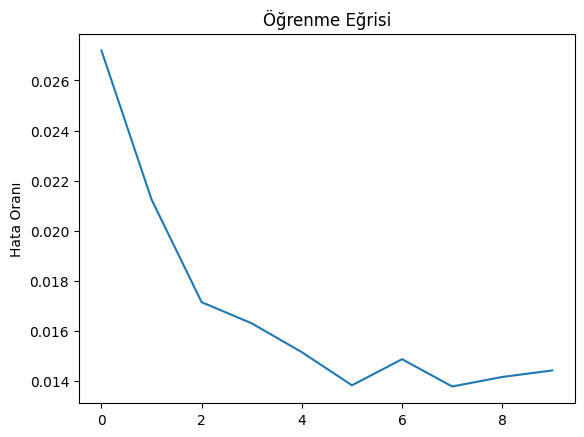

In [4]:
epochs = 10
loss_history = []

for epoch in range(epochs):
    for data in train_loader:
        img, _ = data
        img = img.to(device)
        
        # Girişe gürültü ekle
        noisy_img = add_noise(img)
        
        # Forward pass (Model temizlemeye çalışıyor)
        output, _ = model(noisy_img)
        loss = criterion(output, img) # Çıktıyı temiz orijinal ile kıyasla
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    loss_history.append(loss.item())
    print(f"Epoch {epoch+1} tamamlandı. Loss: {loss.item():.4f}")

# Hata Grafiği
plt.plot(loss_history)
plt.title("Öğrenme Eğrisi")
plt.ylabel("Hata Oranı")
plt.show()

 Not: "Burada modele kirli resimleri gösterdik ama ondan temiz halini üretmesini istedik. Hata grafiğinin düşmesi, modelin artık gürültüyü ayırt edebildiğini gösteriyor."

5. Adım: Final Gösterimi (Bottleneck + Gürültü Temizleme)

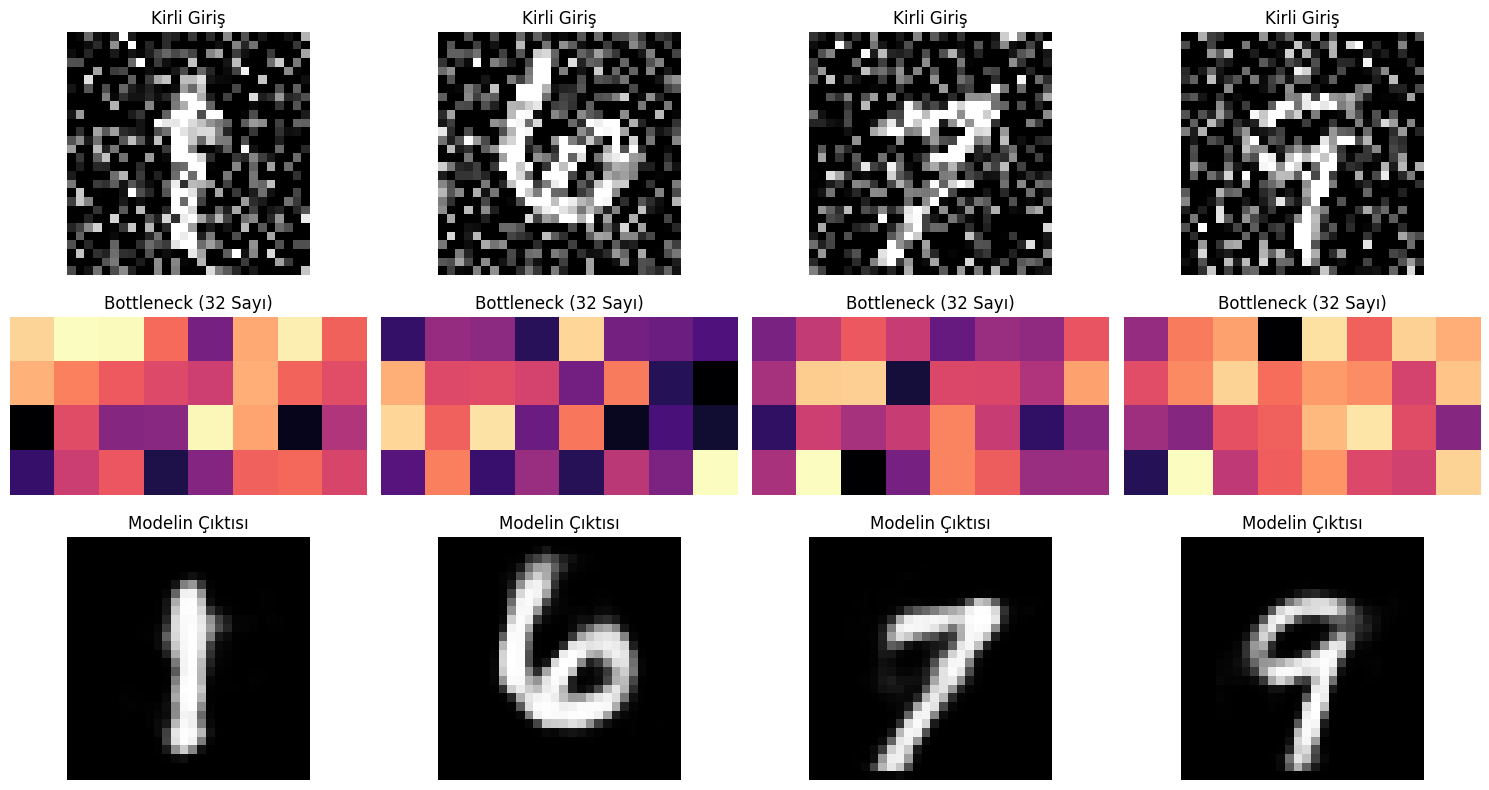

In [5]:
model.eval()
with torch.no_grad():
    dataiter = iter(train_loader)
    images, _ = next(dataiter)
    images = images.to(device)
    
    noisy_images = add_noise(images)
    reconstructed, latents = model(noisy_images)

    # Görselleştirme
    plt.figure(figsize=(15, 8))
    for i in range(4):
        # 1. Gürültülü Giriş
        plt.subplot(3, 4, i + 1)
        plt.imshow(noisy_images[i].cpu().squeeze(), cmap='gray')
        plt.title("Kirli Giriş")
        plt.axis('off')

        # 2. Bottleneck (Gizli Temsil)
        plt.subplot(3, 4, i + 5)
        plt.imshow(latents[i].cpu().view(4, 8), cmap='magma')
        plt.title("Bottleneck (32 Sayı)")
        plt.axis('off')

        # 3. Temizlenmiş Çıktı
        plt.subplot(3, 4, i + 9)
        plt.imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
        plt.title("Modelin Çıktısı")
        plt.axis('off')

    plt.tight_layout()
    plt.show()